In [61]:
import matplotlib.pyplot as plt
import numpy as np
import os
from glob import glob
from astropy.visualization import ImageNormalize, LogStretch
from matplotlib.cm import ScalarMappable
from torch.nn import functional as F
import h5py
import torch

plt.style.use("science")

In [40]:
from functorch import vmap

def interpolate(image, coordinates):
    """
    Interpolation function, without a batch size. To make it batched, used vmap from functorch.
    """
    C, H, W = image.shape
    x, y = torch.tensor_split(coordinates, 2, dim=0)
    x = x.view(-1)
    y = y.view(-1)
    x0 = torch.floor(x).long()
    x1 = x0 + 1
    y0 = torch.floor(y).long()
    y1 = y0 + 1

    x0 = torch.clip(x0, 0, W - 1)
    x1 = torch.clip(x1, 0, W - 1)
    y0 = torch.clip(y0, 0, H - 1)
    y1 = torch.clip(y1, 0, H - 1)
    x = torch.clip(x, 0, W - 1)
    y = torch.clip(y, 0, H - 1)

    Ia = image[..., x0, y0]
    Ib = image[..., x0, y1]
    Ic = image[..., x1, y0]
    Id = image[..., x1, y1]

    wa = (x1 - x) * (y1 - y)
    wb = (x1 - x) * (y - y0)
    wc = (x - x0) * (y1 - y)
    wd = (x - x0) * (y - y0)

    _, new_H, new_W = coordinates.shape
    return (wa * Ia + wb * Ib + wc * Ic + wd * Id).view(C, new_H, new_W)

batched_interpolation = vmap(interpolate, in_dims=(0, None))

In [56]:
files = glob("../results/skirt_g_hst_mock_psf_deconvolution_468*.h5")
files = [f for f in files if f != '../results/skirt_g_hst_mock_psf_deconvolution_468_1.h5']

hf = h5py.File(files[0])
psf = hf["psf"][:]
observation = hf["observation"][:]
ground_truth = np.load("../data/ground_truth468.npy")

observation_pixels = 128
observation_pixel_size = 0.04
model_pixels = 256
model_pixel_size = 0.02
super_sampling_factor = 4
zero_padding = 0

psf = torch.tensor(psf)[None, None]
C = 1

fov = observation_pixel_size * observation_pixels
x = torch.linspace(-1, 1, super_sampling_factor*observation_pixels).float() * fov / 2
x, y = torch.meshgrid(x, x, indexing="ij")  # TODO make this coherent with WCS
# Transform these coordinates into model pixel indices
_min = - model_pixel_size * (model_pixels + zero_padding) / 2
i_coord = (x - _min) / model_pixel_size
j_coord = (y - _min) / model_pixel_size
coordinates = torch.stack([i_coord, j_coord], dim=0)
def A(x):
    x = F.pad(x, pad=[zero_padding]*4, mode="constant", value=0.)
    x = batched_interpolation(x, coordinates)
    x = F.conv2d(x, psf, groups=C, padding="same")
    x = F.avg_pool2d(x, kernel_size=super_sampling_factor, stride=super_sampling_factor)
    return x

../results/skirt_g_hst_mock_psf_deconvolution_468_3.h5
../results/skirt_g_hst_mock_psf_deconvolution_468_4.h5
../results/skirt_g_hst_mock_psf_deconvolution_468_6.h5
../results/skirt_g_hst_mock_psf_deconvolution_468_6.h5
../results/skirt_g_hst_mock_psf_deconvolution_468_7.h5


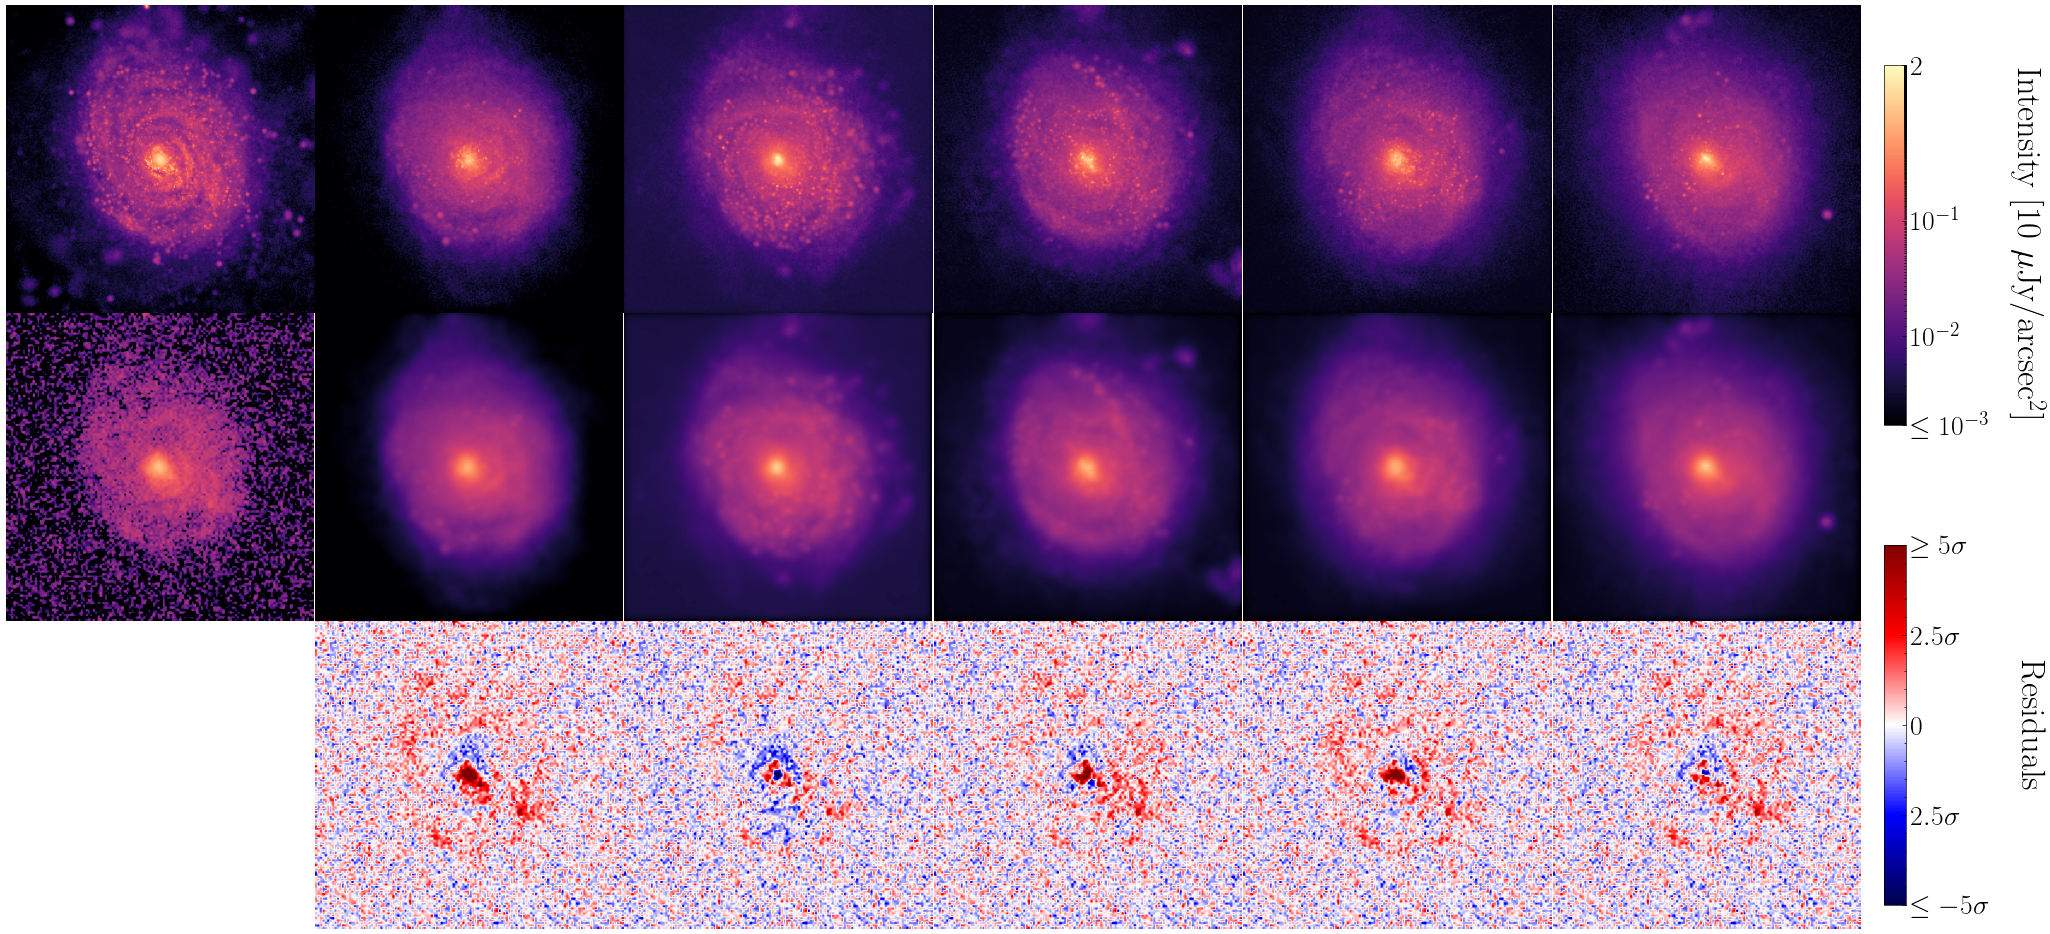

In [72]:
fig, axs = plt.subplots(3, 6, figsize=(22.5, 12))

_max = 2

axs[0, 0].imshow(ground_truth, cmap="magma", norm=ImageNormalize(stretch=LogStretch(),vmax=_max, vmin=1e-3))
axs[1, 0].imshow(observation, cmap="magma", norm=ImageNormalize(stretch=LogStretch(),vmax=_max, vmin=1e-3))
for j in range(5):
    f = files[np.random.randint(len(files))]
    print(f)
    d = h5py.File(f, "r")
    k = np.random.randint(d["model"].shape[0])
    axs[0, j+1].imshow(d["model"][k].squeeze(), cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=_max, vmin=1e-3))
    y_hat = A(torch.tensor(d["model"][k][None])).numpy().squeeze()
    axs[1, j+1].imshow(y_hat, cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=_max, vmin=1e-3))
    axs[2, j+1].imshow((observation - y_hat)/2e-2, cmap="seismic", vmin=-5, vmax=5)

    
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.33 + .2, 0.01, 0.3])
fig.colorbar(ScalarMappable(cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=_max, vmin=1e-3)), cax=cbar_ax, ticks=[0.001, 0.01, 0.1, 2.])
cbar_ax.set_yticklabels(["$\leq 10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", "2"], fontsize=20) 
cbar_ax.set_ylabel(r"Intensity [10 $\mu$Jy/arcsec$^2$]", rotation=270, labelpad=40, fontsize=25)
cbar_ax.yaxis.set_label_position("right")


fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.13, 0.01, 0.3])
fig.colorbar(ScalarMappable(cmap="seismic", norm=ImageNormalize(vmin=-1, vmax=1)), cax=cbar_ax, ticks=[-1, -0.5, 0, 0.5, 1])
cbar_ax.set_yticklabels(["$\leq -5\sigma$", "$2.5\sigma$", "0", "$2.5\sigma$", "$\geq 5\sigma$"], fontsize=20) 
cbar_ax.set_ylabel(r"Residuals", rotation=270, labelpad=40, fontsize=25)
cbar_ax.yaxis.set_label_position("right")


for i in range(3):
    for j in range(6):
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("results1.png")

In [73]:
mean = 0
for f in files:
    mean += h5py.File(f, "r")["model"][:].mean(axis=0)
mean /= len(files)
variance = 0
for f in files:
    variance += ((h5py.File(f, "r")["model"][:] - mean)**2).mean(axis=0)
variance /= len(files)



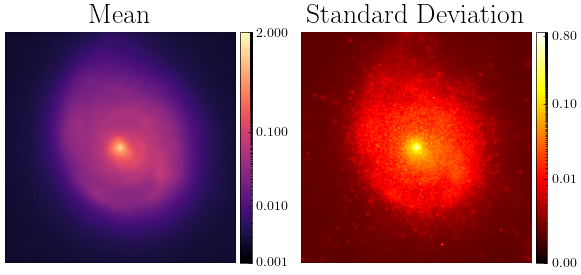

In [87]:
fig, axs = plt.subplots(1, 2, figsize=(7, 4))
from mpl_toolkits.axes_grid1 import make_axes_locatable

im1 = axs[0].imshow(mean.squeeze(), cmap="magma", norm=ImageNormalize(stretch=LogStretch(), vmax=_max, vmin=1e-3))
axs[0].set_title("Mean", fontsize=20)

divider = make_axes_locatable(axs[0])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im1, cax=cax, orientation='vertical', ticks=[1e-3, 1e-2, 1e-1, 2])

im2 = axs[1].imshow(np.sqrt(variance).squeeze(), cmap="hot", norm=ImageNormalize(stretch=LogStretch(), vmin=0))
axs[1].set_title("Standard Deviation", fontsize=20)


divider = make_axes_locatable(axs[1])
cax = divider.append_axes('right', size='5%', pad=0.05)
fig.colorbar(im2, cax=cax, orientation='vertical', ticks=[0., 1e-2, 1e-1, 0.8])

axs[0].axis("off")
axs[1].axis("off")
plt.savefig("results2.png")

In [88]:
noise_samples = np.load("../data/noise_samples.npy")

In [89]:
noise_samples.shape

(1000, 6, 128, 128)

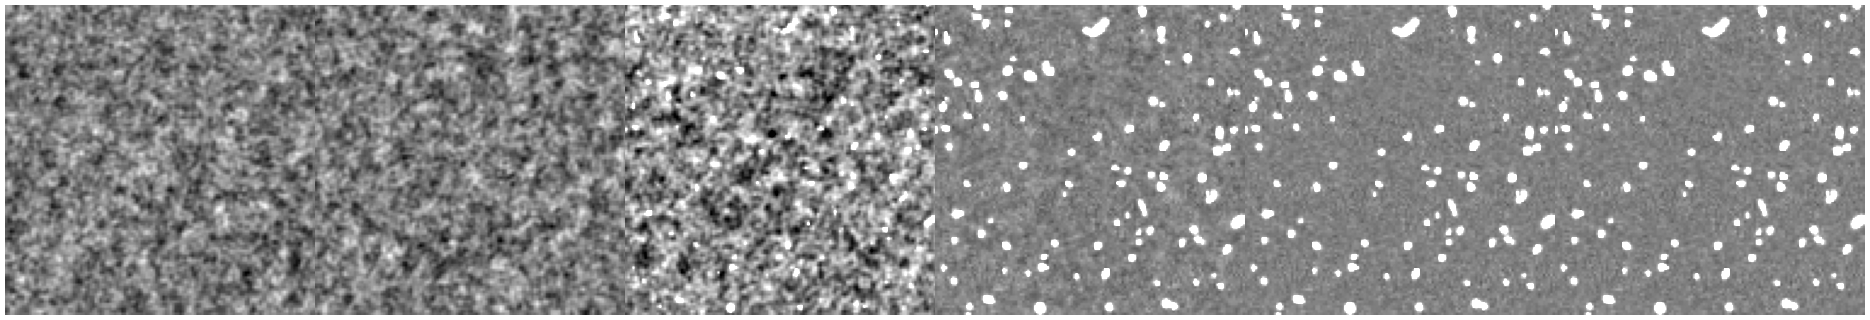

In [105]:
fig, axs = plt.subplots(1, 6, figsize=(24, 8))

for i in range(6):
    k = [0, 200, 400, 600, 800, 999][i]
    _vmin = [None, None, -0.3, -0.04, -0.04, -0.04]
    _vmax = [None, None, 0.3, 0.08, 0.08, 0.08]
    axs[i].imshow(noise_samples[k, 0], cmap="gray", vmin=_vmin[i], vmax=_vmax[i])
    axs[i].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)
plt.savefig("noise.png")